In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import csv
import psutil
import time
# from memory_profiler import profile
import pandas as pd
import pm4py
from pm4py.discovery import discover_petri_net_alpha, discover_petri_net_inductive


In [3]:
logs = [
        # 'bpic2012',
        'bpic2017', 
        #'trafficFines',
        ]


# standardize column names: ['case_id', 'activity', 'resource', 'timestamp'] for all logs
case_id_col = 'case_nr'
activity_col = 'activity'
resource_col = 'resource'
timestamp_col = 'timestamp'

# dataset_name: [case_id_col, activity_col, resource_col, timestamp_col]
# NOTE - Basic column names are defined by users. These names will be renamed and standardized later 
# standardize column names: ['case_id', 'activity', 'resource', 'timestamp']
dataset_dict = {
    'bpic2012': ['case_id', 'activity', 'resource', 'start_time'],
    'bpic2017': ['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp'],
    #'trafficFines': ['case:concept:name', 'concept:name', 'org:resource', "time:timestamp"], 
}
incomplete_dict = {
    'bpic2012': ["A_APPROVED", "A_REGISTERED", "A_ACTIVATED", "A_CANCELLED", "A_DECLINED"],
    'bpic2017': ["A_Pending", "A_Denied", "A_Cancelled",],
    #'trafficFines': ["Send for Credit Collection"]
}


# Define positive and negative labels
label_old = "outcome"
neg_label = 0
pos_label = 1
positive_activities_dict = {
    'bpic2017': ["A_Pending"],
    'bpic2012': ["A_APPROVED", "A_REGISTERED", "A_ACTIVATED",],
    #'trafficFines': ["Send for Credit Collection"]
}

chunk_s = 10000

In [3]:
class DataPreprocessorModinDask:
    def __init__(self, log_name, input_data_path):
        self.log_name = log_name
        self.input_data_path = input_data_path

    def _print_metrics(self, elapsed_time):
        # Helper function to print resource usage metrics
        cpu_percent = psutil.cpu_percent()
        memory_info = psutil.virtual_memory()

    # @profile
    def read_log(self):
        start_time = time.time()
        print("Reading log...")

        # Read the log based on its extension
        if self.input_data_path.lower().endswith('.csv'):
            with open(self.input_data_path, 'r') as file:
                # Use Sniffer to infer the delimiter
                dialect = csv.Sniffer().sniff(file.read(10000))
            try:
                # Read CSV with Dask, specifying dtype for certain columns
                log_file = pd.read_csv(self.input_data_path, sep=dialect.delimiter, dtype={'Resource': 'object', 'article': 'object'})
            except:
                log_file = pd.read_csv(self.input_data_path, sep=dialect.delimiter)

            log_file = log_file.rename(columns=lambda x: x.strip().lower().replace(' ', '_'))
            log_file = log_file.rename(
                columns=dict(zip(dataset_dict[self.log_name], [case_id_col, activity_col, resource_col, timestamp_col])))
        else:
            raise ValueError("Unsupported file extension. Supported extensions: .csv, .xes")

        # Calculate elapsed time and print resource usage metrics
        end_time = time.time()
        elapsed_time = end_time - start_time
        self._print_metrics(elapsed_time)
        return log_file

    # @profile
    def clean_data(self, log_file):
        start_time = time.time()
        print("Cleaning data...")

        # Convert timestamp column to datetime
        print(f"Before conversion: {log_file[timestamp_col].dtype}")
        log_file[timestamp_col] = pd.to_datetime(log_file[timestamp_col], format="mixed", infer_datetime_format=True)
        log_file = log_file.sort_values(by=[timestamp_col])
        print(f"After conversion: {log_file[timestamp_col].dtype}")

       # Remove white spaces from column values
        log_file = log_file.applymap(lambda x: x.strip() if isinstance(x, str) else x)

        # Convert the 'resource' column to string
        log_file[resource_col] = log_file[resource_col].astype(str)

        # Replace unique resource values with 'res{i}' format
        unique_resources = log_file[resource_col].unique()
        resource_mapping = {original_value: f'res{i + 1}' for i, original_value in enumerate(unique_resources)}
        log_file[resource_col] = log_file[resource_col].replace(resource_mapping)

        # Make sure that a 0 in the following columns is replaced by NaN
        if self.log_name == 'bpic2017':
            columns_to_check = ['firstwithdrawalamount', 'monthlycost', 'creditscore', 'offeredamount', "numberofterms"]
            log_file[columns_to_check] = log_file[columns_to_check].replace(0, pd.NA)

        # There are some columns that have NaN up until a certain point in a case, then they are filled in one row. Make sure that they have the same value starting from the first occurrence up until the next change
        filled_file = log_file.groupby(case_id_col, group_keys=False).ffill()
        # make sure to have column case_id_col still in the dataframe
        filled_file[case_id_col] = log_file[case_id_col]
        log_file = filled_file

        # activities_to_check = incomplete_dict[log_name]  # ["A_APPROVED", "A_REGISTERED", "A_ACTIVATED", "A_CANCELLED", "A_DECLINED"]
        activities_to_check = incomplete_dict[self.log_name]  # ["A_APPROVED", "A_REGISTERED", "A_ACTIVATED", "A_CANCELLED", "A_DECLINED"]              
        contains_activity = log_file[activity_col].isin(activities_to_check).groupby(log_file[case_id_col]).max().reset_index()
        complete_cases = contains_activity[contains_activity[activity_col] == True][case_id_col]
        log_file = log_file[log_file[case_id_col].isin(complete_cases.tolist())]       

        # Calculate elapsed time and print resource usage metrics
        end_time = time.time()
        elapsed_time = end_time - start_time
        self._print_metrics(elapsed_time)
        return log_file
    
    # @profile
    def extract_temporal_features(self, log_file):
        start_time = time.time()
        print("Extracting timestamp features...")

        # Calculate event_nr
        log_file['event_nr'] = log_file.groupby(case_id_col).cumcount() + 1

        # Calculate case_length
        log_file['case_length'] = log_file.groupby(case_id_col)['event_nr'].transform('max')

        log_file['elapsed_time'] = log_file[timestamp_col] - log_file.groupby(case_id_col)[timestamp_col].transform('min')
        log_file['elapsed_time'] = log_file['elapsed_time'].dt.total_seconds()

        # Calculate elapsed time and print resource usage metrics
        end_time = time.time()
        elapsed_time = end_time - start_time
        self._print_metrics(elapsed_time)

        return log_file

In [4]:
# Usage example:
# Initialize your DataPreprocessorModinDask object and call read_log() and clean_data()
for log_name in logs:
    print("\n==================\n Log: %s\n==================\n" % (log_name,))
    input_data_path = "%s.csv" % (log_name)
    output_data_path = "prep_%s" % log_name

    data_preprocessor = DataPreprocessorModinDask(log_name, input_data_path=input_data_path)
    log_file = data_preprocessor.read_log()
    cleaned_data = data_preprocessor.clean_data(log_file)
    features_data = data_preprocessor.extract_temporal_features(cleaned_data)
    print(f"After conversion: {features_data[timestamp_col].dtype}")
    features_data.name = "%s_cleaned.csv" % log_name
    
    print("Saving csv file...")
    results_dir = "res_%s" % log_name
    import os

    if not os.path.exists(os.path.join(results_dir)):
        os.makedirs(os.path.join(results_dir))

    features_data.to_csv(
        os.path.join(
            results_dir, features_data.name
        ),
        index=False,
        sep=";",
    )

    print("Done!")


 Log: bpic2017

Reading log...
Cleaning data...
Before conversion: object
After conversion: datetime64[ns, UTC]
Extracting timestamp features...
After conversion: datetime64[ns, UTC]
Saving csv file...
Done!


In [4]:
og_log = pd.read_csv("bpic2017.csv")
log = pd.read_csv("res_bpic2017\\bpic2017_cleaned.csv", sep=";", parse_dates=[timestamp_col])
log[timestamp_col] = pd.to_datetime(log[timestamp_col], format="mixed", infer_datetime_format=True)
print(f"After conversion: {log[timestamp_col].dtype}")

datetime_cols = {x for x in log.columns if "date" in str(log[x].dtype).lower() 
                 or "time" in str(log[x].dtype).lower()}

# Step 3: If no datetime-like columns detected, convert "time:timestamp"
if not datetime_cols:  # sets don't have .empty, use `if not set:`
    log[timestamp_col] = pd.to_datetime(log[timestamp_col], infer_datetime_format=True)
    datetime_cols = {timestamp_col}

print(datetime_cols)
print(log[timestamp_col].head())


After conversion: datetime64[ns, UTC]
{'timestamp'}
0   2016-01-01 09:51:15.304000+00:00
1   2016-01-01 09:51:15.352000+00:00
2   2016-01-01 09:51:15.774000+00:00
3   2016-01-01 09:52:36.392000+00:00
4   2016-01-01 09:52:36.403000+00:00
Name: timestamp, dtype: datetime64[ns, UTC]


In [15]:
# Check if there are any missing values
missing_count = log[timestamp_col].isna().sum()

# Optionally print which rows are missing
missing_rows = log[log[timestamp_col].isna()]

print(f"Number of missing or invalid timestamps: {missing_count}")
print(missing_rows.head())  # show a few examples if there are any

Number of missing or invalid timestamps: 0
Empty DataFrame
Columns: [unnamed:_0, action, resource, activity, eventorigin, eventid, lifecycle:transition, timestamp, case:loangoal, case:applicationtype, case:requestedamount, firstwithdrawalamount, numberofterms, accepted, monthlycost, selected, creditscore, offeredamount, offerid, case_nr, event_nr, case_length, elapsed_time]
Index: []

[0 rows x 23 columns]


In [5]:
# Only keep rows where activity starts with W_
log = log[log['activity'].str.startswith("W_")]

log['event_nr'] = log.groupby('case_nr').cumcount()

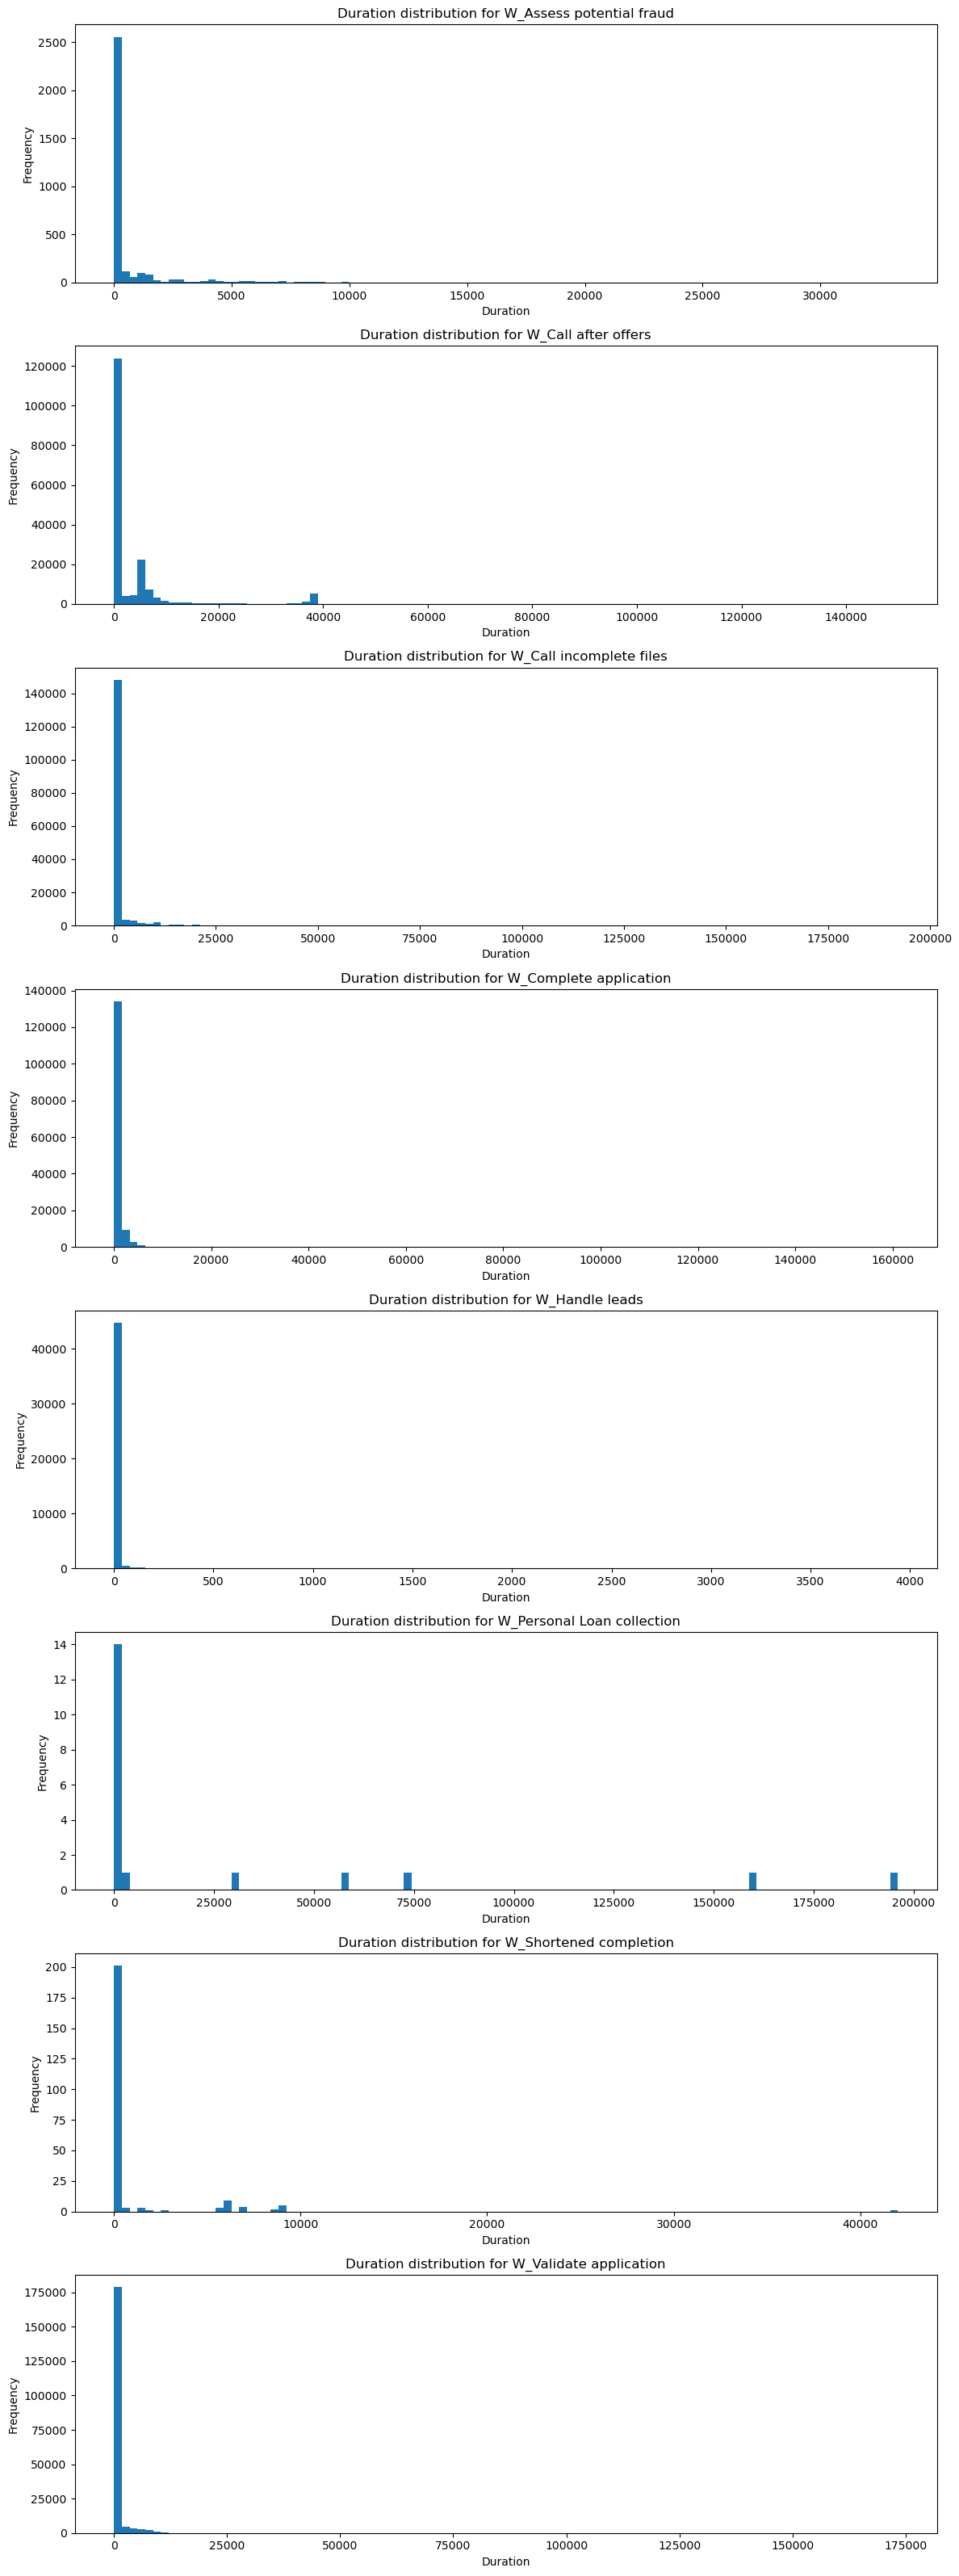

                     activity          mean           std   count
4              W_Handle leads     28.629544    177.289506   47066
3      W_Complete application    477.697515   1629.458322  148025
7      W_Validate application    481.713791   1588.498384  193440
0    W_Assess potential fraud    554.952904   1765.419460    3180
2     W_Call incomplete files    816.740904   3210.512418  161627
6      W_Shortened completion    926.202876   3448.351758     233
1         W_Call after offers   3808.815381   9074.362537  181120
5  W_Personal Loan collection  25959.795382  56217.297152      20


In [12]:
# Compute duration to next event within each case
log['duration'] = log.groupby('case_nr')['timestamp'].shift(-1) - log['timestamp']

log_dur = log

# Drop the last event per case (since it has no next timestamp)
log_dur['duration'] = log['duration'].dt.total_seconds() / 60

# --- 7. Plot a distribution per activity
activities = log_dur['activity'].unique()
n_acts = len(activities)

plt.figure(figsize=(12, 4 * n_acts))

for i, act in enumerate(sorted(activities), 1):
    plt.subplot(n_acts, 1, i)
    plt.hist(log_dur.loc[log_dur['activity'] == act, 'duration'], bins=100)
    plt.title(f"Duration distribution for {act}")
    plt.xlabel("Duration")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

activity_stats = (
    log.groupby('activity')['duration']
       .agg(['mean', 'std', 'count'])
       .reset_index()
       .sort_values('mean')
)

print(activity_stats)

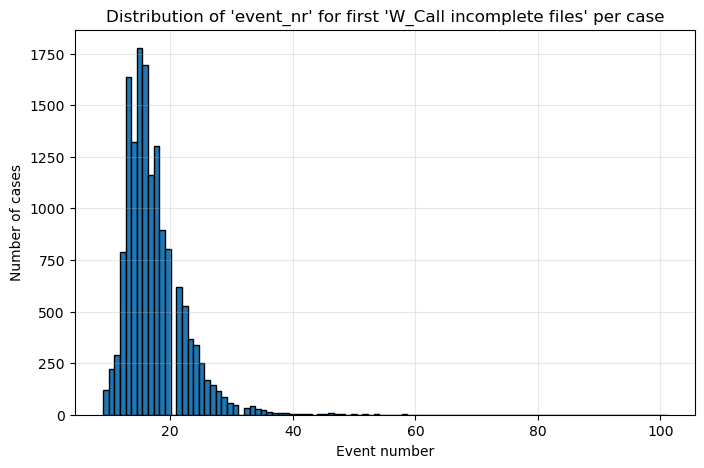

In [17]:
# Step 1: For each case, find the first occurrence of 'W_Call incomplete offers'
first_call_rows = (
    log[log['activity'] == 'W_Call incomplete files']
    .groupby('case_nr', as_index=False)
    .first()
)

# Step 2: Extract the event_nr values
event_numbers = first_call_rows['event_nr']

# Step 3: Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(event_numbers, bins=100, edgecolor='black')
plt.title("Distribution of 'event_nr' for first 'W_Call incomplete files' per case")
plt.xlabel("Event number")
plt.ylabel("Number of cases")
plt.grid(alpha=0.3)
plt.show()

In [18]:
log = log.sort_values(['case_nr', 'event_nr'])

# Find the index of the first 'W_Call incomplete files' per case
first_incomplete_idx = (
    log[log['activity'] == 'W_Call incomplete files']
    .groupby('case_nr', as_index=False)
    .first()
    .index
)

# Get the corresponding previous rows (one row before each)
previous_rows = log.iloc[first_incomplete_idx - 1]

# Print unique activity values that occur before the first 'W_Call incomplete files'
print(previous_rows['activity'].unique())

['W_Call incomplete files' 'W_Handle leads' 'W_Complete application'
 'W_Call after offers' 'W_Validate application' 'W_Assess potential fraud'
 'W_Shortened completion']


# Petri Nets and flow

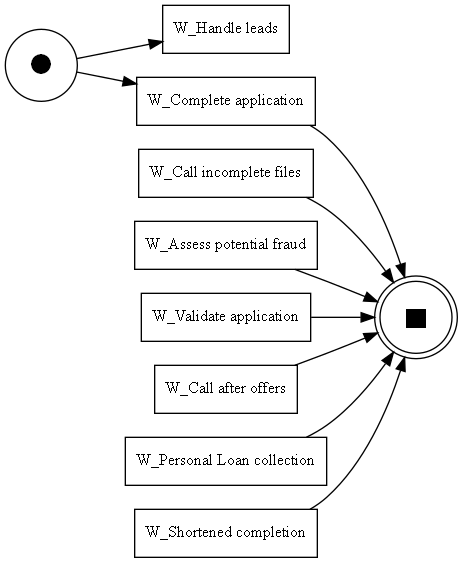

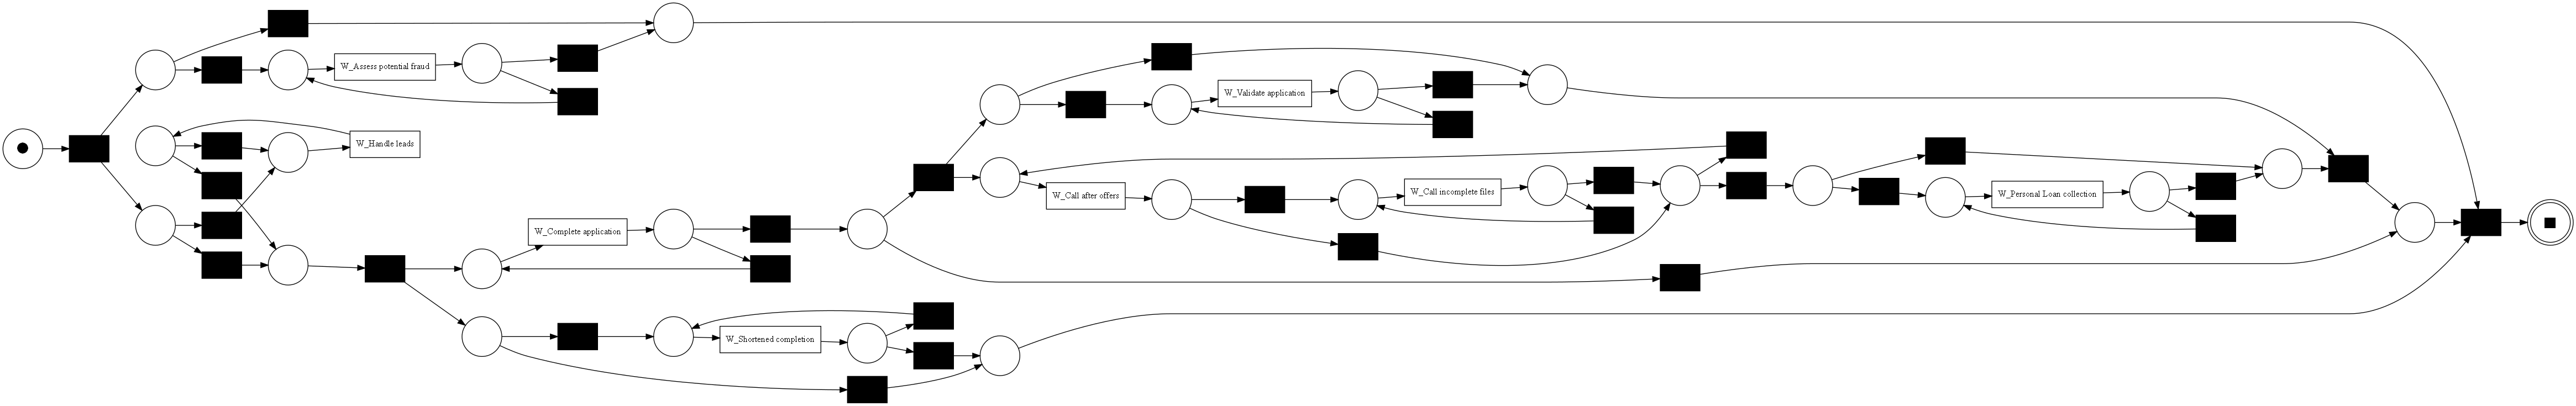

In [29]:
# do a process discovery on the log using alpha, heuristics, and inductive miner
net, initial_marking, final_marking = discover_petri_net_alpha(log, activity_key=activity_col, timestamp_key=timestamp_col, case_id_key=case_id_col)
gviz = pm4py.visualization.petri_net.visualizer.apply(net, initial_marking, final_marking)
pm4py.visualization.petri_net.visualizer.view(gviz)
net, initial_marking, final_marking = discover_petri_net_inductive(log, noise_threshold=0, activity_key=activity_col, timestamp_key=timestamp_col, case_id_key=case_id_col)
gviz = pm4py.visualization.petri_net.visualizer.apply(net, initial_marking, final_marking)
pm4py.visualization.petri_net.visualizer.view(gviz)

In [2]:
from pm4py.objects.conversion.log.variants import to_data_frame

In [3]:
# get as a dataframe
df = to_data_frame.apply(log)